# Homework 1 - Convolutions

In [19]:
begin
    import Pkg
    Pkg.activate(mktempdir())
end

  Activating new project at `C:\Users\msule\AppData\Local\Temp\jl_YhQkAa`


In [20]:
begin
    Pkg.add(["Images", "ImageMagick"])
    using Images
end

   Resolving package versions...
    Updating `C:\Users\msule\AppData\Local\Temp\jl_YhQkAa\Project.toml`
  [6218d12a] + ImageMagick v1.4.0
  [916415d5] + Images v0.26.1
    Updating `C:\Users\msule\AppData\Local\Temp\jl_YhQkAa\Manifest.toml`
  [621f4979] + AbstractFFTs v1.5.0
  [79e6a3ab] + Adapt v4.1.1
  [ec485272] + ArnoldiMethod v0.4.0
  [4fba245c] + ArrayInterface v7.17.1
  [13072b0f] + AxisAlgorithms v1.1.0
  [39de3d68] + AxisArrays v0.4.7
  [62783981] + BitTwiddlingConvenienceFunctions v0.1.6
  [fa961155] + CEnum v0.5.0
  [2a0fbf3d] + CPUSummary v0.2.6
  [aafaddc9] + CatIndices v0.2.2
  [d360d2e6] + ChainRulesCore v1.25.0
  [fb6a15b2] + CloseOpenIntervals v0.1.13
  [aaaa29a8] + Clustering v0.15.7
  [35d6a980] + ColorSchemes v3.27.1
  [3da002f7] + ColorTypes v0.12.0
  [c3611d14] + ColorVectorSpace v0.11.0
  [5ae59095] + Colors v0.13.0
  [f70d9fcc] + CommonWorldInvalidations v1.0.0
  [34da2185] + Compat v4.16.0
  [ed09eef8] + ComputationalResources v0.3.2
  [187b0558] + Constructio

In [21]:
bigbreak = html"<br><br><br><br><br>";

## Exercise 1 - Manipulating Vectors (1D images)

A Vector is a 1D array. We can think of that as a 1D image.

In [22]:
example_vector = [0.5, 0.4, 0.3, 0.2, 0.1, 0.0, 0.7, 0.0, 0.7, 0.9]

10-element Vector{Float64}:
 0.5
 0.4
 0.3
 0.2
 0.1
 0.0
 0.7
 0.0
 0.7
 0.9

In [23]:
begin
    colored_line(x::Vector{<:Real}) = Gray.(Float64.((hcat(x)')))
    colored_line(x::Any) = nothing
end

colored_line (generic function with 2 methods)

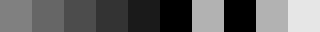

In [24]:
colored_line(example_vector)

### Exercise 1.1

Make a random vector random_vect of length 10 using the rand function.

In [25]:
random_vect = rand(Int64, 10)

10-element Vector{Int64}:
 -3558820816317508142
 -8008211278559926162
 -2198328313075654692
  3004993624065234407
 -4807570984072895728
  2022999867284881830
 -3649493810587738222
 -3950910161823464153
  8090139308220357798
 -7830702501677980424

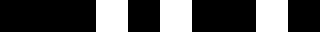

In [26]:
colored_line(random_vect)

Make a function mean using a for loop, which computes the mean/average of a vector of numbers.

In [27]:
function mean(x)
	x_sum = 0
	for n in x
		x_sum += n
	end
	return x_sum / length(x)
end

mean (generic function with 1 method)

In [28]:
mean([1, 2, 3])

2.0

Define m to be the mean of random_vect.

In [29]:
m = mean(random_vect)

-2.4391609928351418e17

Write a function demean, which takes a vector x and subtracts the mean from each value in x.

In [30]:
function demean(x)
	mean_x = mean(x)
	for (i, n) in enumerate(x)
		x[i] = n - mean_x
	end
	return x
end

demean (generic function with 1 method)

In [31]:
mean(demean(random_vect))

153.6

### Exercise 1.2

Generate a vector of 100 zeros. Change the center 20 elements to 1.

In [32]:
function create_bar()
    vect = zeros(Int, 100)
    vect[40:60] .= 1
	return vect
end

create_bar (generic function with 1 method)

In [33]:
colored_line(create_bar())

### Exercise 1.3

Write a function that turns a Vector of Vectors into a Matrix.

In [34]:
function vecvec_to_matrix(vecvec)
	return hcat(vecvec...)
end

vecvec_to_matrix (generic function with 1 method)

In [35]:
vecvec_to_matrix([[1,2], [3,4]])

2×2 Matrix{Int64}:
 1  3
 2  4

Write a function that turns a Matrix into a Vector of Vectors.

In [36]:
function matrix_to_vecvec(matrix)
    return [col for col in eachcol(matrix)]
end

matrix_to_vecvec (generic function with 1 method)

In [37]:
matrix_to_vecvec([6 7; 8 9])

2-element Vector{SubArray{Int64, 1, Matrix{Int64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}:
 [6, 8]
 [7, 9]